In [1]:
# Imports as always...
from pathlib import Path
import itertools

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

import matplotlib.pyplot as plt
import cmcrameri.cm as cmc
import seaborn as sns
palette = 'deep'
colours = cmc.berlin
sns.set_theme(style='darkgrid', palette=palette)

import warnings
warnings.filterwarnings("ignore")

In [2]:
seed = 42
rng = np.random.default_rng(seed)

# Time-Varied Experiments

In [3]:
# Reading in the data...

data_path = './data/time-varied/master.csv'

raw_data = pd.read_csv(data_path)
raw_data["device"] = raw_data["device"].replace({"Aria 1": "Aria-1"})
raw_data["completion_time"] = pd.to_datetime(raw_data["completion_time"], utc=True)
raw_data = raw_data.sort_values(["device", "batch", "completion_time", "step"]).reset_index(drop=True)

bitstrings = [format(i, "05b") for i in range(32)]
x_cols = [f"x{b}" for b in bitstrings]

n_qubits = len(bitstrings[0])
n_shots = int(raw_data["n_shots"].mode().iloc[0])
shot_floor = 1.0 / n_shots

In [4]:
# Deterministic post-processing maps...

# Ideal GHZ distribution.
ideal = pd.Series(0.0, index=x_cols)
ideal["x00000"] = 0.5
ideal["x11111"] = 0.5
ideal_vec = ideal.to_numpy(dtype=float)

bits = np.array([[int(bit) for bit in bitstring] for bitstring in bitstrings], dtype=int)
z_signs = 1 - 2 * bits  # 0 -> +1, 1 -> -1
zz_pairs = list(itertools.combinations(range(n_qubits), 2))
zz_signs = np.stack([z_signs[:, i] * z_signs[:, j] for i, j in zz_pairs], axis=1)

ideal_qubit_one = ideal_vec @ bits
ideal_z = ideal_vec @ z_signs
ideal_zz = ideal_vec @ zz_signs

def observed_matrix(data_df):
    x = data_df[x_cols].to_numpy(dtype=float)
    x = np.clip(x, 0.0, None)
    totals = x.sum(axis=1, keepdims=True)
    totals[totals == 0] = 1.0
    return x / totals

def entropy_rows(x, eps=1e-12):
    p = np.clip(x, eps, 1.0)
    return -(p * np.log2(p)).sum(axis=1)

# Compute features on the dataset.
def make_features(data_df, feature_type):
    x = observed_matrix(data_df)
    residual = x - ideal_vec

    if feature_type == "raw":
        return x
    elif feature_type == "res":
        return residual
    elif feature_type == "abs_res":
        return np.abs(residual)
    elif feature_type == "rel_res":
        return residual / (ideal_vec + shot_floor)
    elif feature_type == "abs_rel_res":
        return np.abs(residual / (ideal_vec + shot_floor))
    elif feature_type == "log_ratio":
        return np.log((x + shot_floor) / (ideal_vec + shot_floor))
    elif feature_type == "qubit_res":
        return (x @ bits) - ideal_qubit_one
    elif feature_type == "abs_qubit_res":
        return np.abs((x @ bits) - ideal_qubit_one)
    elif feature_type == "pauli_z_res":
        return (x @ z_signs) - ideal_z
    elif feature_type == "pauli_zz_res":
        return (x @ zz_signs) - ideal_zz
    elif feature_type == "bell_summary":
        p0 = x[:, 0]
        p1 = x[:, -1]
        leakage = 1.0 - p0 - p1
        l1_to_ideal = np.abs(residual).sum(axis=1)
        entropy = entropy_rows(x)
        return np.column_stack([p0, p1, leakage, p0 - p1, l1_to_ideal, entropy])

    raise ValueError(f"I have no idea what this is: {feature_type}")

feature_name_map = {
    "raw": "Raw",
    "res": "Residual",
    "abs_res": "Residual (absolute)",
    "rel_res": "Residual (relative)",
    "abs_rel_res": "Residual (absolute, relative)",
    "log_ratio": "Log ratio",
    "qubit_res": "Residual (per qubit)",
    "abs_qubit_res": "Residual (absolute, per qubit)",
    "pauli_z_res": "Pauli-Z expectation",
    "bell_summary": "Bell summary",
}

# For making neural network shapes a little easier.
in_features = {
    feature_type: make_features(raw_data.iloc[:2], feature_type).shape[1]
    for feature_type in feature_name_map
}

## Distance Checks

Optimal success probability (well, the distinguishing bias) is given by the total variation distance between induced transcript laws. A nice (though slightly simplistic) analog of this is to compare the mean output distributions for each device-batch pair; if two batches are close, then classification should be harder.

In [5]:
# Some distance measures.

def total_variation(p, q):
    return 0.5 * np.abs(p - q).sum()

def hellinger(p, q):
    return np.sqrt(0.5 * ((np.sqrt(p) - np.sqrt(q)) ** 2).sum())

def kl_div(p, q, eps=1e-12):
    p = np.clip(p, eps, 1.0)
    q = np.clip(q, eps, 1.0)
    return (p * np.log(p / q)).sum()

def jensen_shannon(p, q):
    m = 0.5 * (p + q)
    return 0.5 * kl_div(p, m) + 0.5 * kl_div(q, m)

def pairwise_batch_distances(data_df, group_col="batch"):
    rows = []
    means = data_df.groupby(group_col)[x_cols].mean().sort_index()
    for a, b in itertools.combinations(means.index, 2):
        p = means.loc[a].to_numpy(dtype=float)
        q = means.loc[b].to_numpy(dtype=float)
        rows.append({
            "group_a": a,
            "group_b": b,
            "tv": total_variation(p, q),
            "hellinger": hellinger(p, q),
            "js": jensen_shannon(p, q),
        })
    return pd.DataFrame(rows)

distance_rows = []
for dev, dev_df in raw_data.groupby("device"):
    if dev_df["batch"].nunique() < 2:
        continue
    distances = pairwise_batch_distances(dev_df)
    distances.insert(0, "device", dev)
    distance_rows.append(distances)

batch_distances = pd.concat(distance_rows, ignore_index=True)
display(batch_distances)

,device,group_a,group_b,tv,hellinger,js
0,Ankaa-3,1,2,0.041162,0.046747,0.002177
1,Ankaa-3,1,3,0.054883,0.087982,0.007540
2,Ankaa-3,2,3,0.048906,0.086790,0.007358
3,Garnet,1,2,0.029883,0.044422,0.001962
4,Garnet,1,3,0.022324,0.032126,0.001028
5,Garnet,2,3,0.018242,0.030392,0.000920


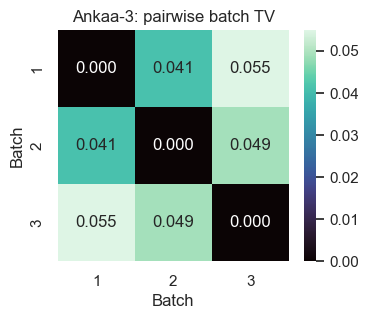

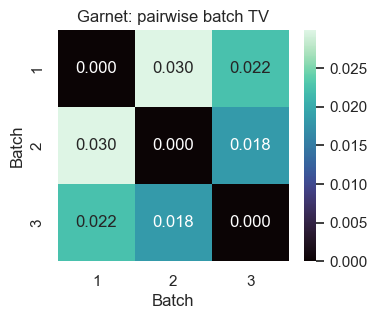

In [6]:
# Heatmaps for the TV distance.

def plot_distance_heatmap(distance_df, device, metric="tv"):
    dev_df = distance_df[distance_df["device"] == device]
    batches = sorted(set(dev_df["group_a"]).union(dev_df["group_b"]))
    mat = pd.DataFrame(np.nan, index=batches, columns=batches, dtype=float)
    for batch in batches:
        mat.loc[batch, batch] = 0.0
    for _, row in dev_df.iterrows():
        mat.loc[row["group_a"], row["group_b"]] = row[metric]
        mat.loc[row["group_b"], row["group_a"]] = row[metric]

    fig, ax = plt.subplots(figsize=(4, 3))
    sns.heatmap(mat, annot=True, fmt=".3f", cmap="mako", square=True, ax=ax)
    ax.set_title(f"{device}: pairwise batch {metric.upper()}")
    ax.set_xlabel("Batch")
    ax.set_ylabel("Batch")
    plt.show()


for dev in batch_distances["device"].unique():
    plot_distance_heatmap(batch_distances, dev, metric="tv")

## Batch Classification

In [7]:
def balanced_subset(data_df, group_cols, n_per_group=None, random_state=seed):
    if isinstance(group_cols, str):
        group_cols = [group_cols]

    counts = data_df.groupby(group_cols).size()
    if counts.empty:
        raise ValueError("No groups available for balancing.")
    if n_per_group is None:
        n_per_group = int(counts.min())

    parts = []
    for _, group in data_df.groupby(group_cols, group_keys=False):
        if len(group) >= n_per_group:
            parts.append(group.sample(n=n_per_group, random_state=random_state))

    if not parts:
        raise ValueError("No groups had enough rows to sample.")

    return pd.concat(parts, ignore_index=True).sample(frac=1, random_state=random_state).reset_index(drop=True)

In [8]:
test_split = .2
val_split = .2

def make_classifier(classifier="mlp", epochs=500, random_state=seed):
    if classifier == "mlp":
        estimator = MLPClassifier(
            hidden_layer_sizes=(256, 64),
            activation="relu",
            alpha=1e-4,
            batch_size=min(64, max(8, len(raw_data) // 10)),
            learning_rate_init=1e-3,
            max_iter=epochs,
            early_stopping=True,
            validation_fraction=val_split,
            n_iter_no_change=50,
            random_state=random_state,
        )
    elif classifier == "logreg":
        estimator = LogisticRegression(
            max_iter=5000,
            class_weight="balanced",
            random_state=random_state,
        )
    else:
        raise ValueError("classifier must be 'mlp' or 'logreg'")

    return make_pipeline(StandardScaler(), estimator)

In [9]:
def experiment_run(
    data_df,
    feature_type,
    label_col="batch",
    classifier="mlp",
    repeats=5,
    epochs=500,
    random_state=seed,
):
    labels = data_df[label_col].astype(str).to_numpy()
    if pd.Series(labels).nunique() < 2:
        raise ValueError(f"Need at least two classes in {label_col}.")

    x = make_features(data_df, feature_type)
    encoder = LabelEncoder()
    y = encoder.fit_transform(labels)
    baseline = pd.Series(y).value_counts(normalize=True).max()

    rows = []
    for repeat in range(repeats):
        split_seed = random_state + repeat
        x_train, x_test, y_train, y_test = train_test_split(
            x,
            y,
            test_size=test_split,
            random_state=split_seed,
            stratify=y,
        )
        model = make_classifier(classifier=classifier, epochs=epochs, random_state=split_seed)
        model.fit(x_train, y_train)
        train_pred = model.predict(x_train)
        test_pred = model.predict(x_test)

        rows.append({
            "repeat": repeat,
            "feature_type": feature_type,
            "classifier": classifier,
            "n_rows": len(data_df),
            "n_classes": len(encoder.classes_),
            "baseline_acc": baseline,
            "train_acc": accuracy_score(y_train, train_pred),
            "test_acc": accuracy_score(y_test, test_pred),
            "balanced_test_acc": balanced_accuracy_score(y_test, test_pred),
        })

    return pd.DataFrame(rows)


def summarize_scores(scores):
    return pd.Series({
        "n_rows": scores["n_rows"].iloc[0],
        "n_classes": scores["n_classes"].iloc[0],
        "baseline_acc": scores["baseline_acc"].iloc[0],
        "train_acc_mean": scores["train_acc"].mean(),
        "test_acc_mean": scores["test_acc"].mean(),
        "test_acc_std": scores["test_acc"].std(ddof=0),
        "balanced_test_acc_mean": scores["balanced_test_acc"].mean(),
        "balanced_test_acc_std": scores["balanced_test_acc"].std(ddof=0),
    })


def feature_sweep(
    data_df,
    feature_types=None,
    label_col="batch",
    classifier="mlp",
    repeats=5,
    epochs=500,
):
    if feature_types is None:
        feature_types = list(in_features.keys())

    rows = []
    raw_scores = []
    for feature_type in feature_types:
        scores = experiment_run(
            data_df,
            feature_type=feature_type,
            label_col=label_col,
            classifier=classifier,
            repeats=repeats,
            epochs=epochs,
        )
        raw_scores.append(scores)
        summary = summarize_scores(scores)
        summary["feature_type"] = feature_type
        summary["feature_name"] = feature_name_map.get(feature_type, feature_type)
        rows.append(summary)

    summary_df = pd.DataFrame(rows).sort_values("test_acc_mean", ascending=False).reset_index(drop=True)
    raw_scores_df = pd.concat(raw_scores, ignore_index=True)
    return summary_df, raw_scores_df

In [10]:
def plot_feature_sweep(results_df, title=None, xlim=None):
    plot_df = results_df.sort_values("test_acc_mean", ascending=True)
    y = np.arange(len(plot_df))
    colors = [colours(i / max(1, len(plot_df) - 1)) for i in range(len(plot_df))]

    fig, ax = plt.subplots(figsize=(7, max(4, 0.35 * len(plot_df))))
    ax.barh(
        y,
        plot_df["test_acc_mean"],
        xerr=plot_df["test_acc_std"],
        color=colors,
        alpha=0.90,
    )
    ax.set_yticks(y)
    ax.set_yticklabels(plot_df["feature_name"])
    ax.axvline(plot_df["baseline_acc"].iloc[0], linestyle="--", color="black", label="Majority baseline")
    ax.set_xlabel("Test accuracy")
    ax.set_title(title or "Batch classification by feature map")
    if xlim is not None:
        ax.set_xlim(*xlim)
    ax.legend(loc="lower right")
    plt.tight_layout()
    plt.show()

,n_rows,n_classes,baseline_acc,train_acc_mean,test_acc_mean,test_acc_std,balanced_test_acc_mean,balanced_test_acc_std,feature_type,feature_name
0,300.0,3.0,0.333333,1.000000,0.990000,0.013333,0.990000,0.013333,raw,Raw
1,300.0,3.0,0.333333,1.000000,0.990000,0.013333,0.990000,0.013333,res,Residual
2,300.0,3.0,0.333333,1.000000,0.990000,0.013333,0.990000,0.013333,abs_res,Residual (absolute)
3,300.0,3.0,0.333333,1.000000,0.990000,0.013333,0.990000,0.013333,rel_res,Residual (relative)
4,300.0,3.0,0.333333,1.000000,0.990000,0.013333,0.990000,0.013333,abs_rel_res,"Residual (absolute, relative)"
5,300.0,3.0,0.333333,1.000000,0.983333,0.014907,0.983333,0.014907,log_ratio,Log ratio
6,300.0,3.0,0.333333,0.940833,0.916667,0.023570,0.916667,0.023570,qubit_res,Residual (per qubit)
7,300.0,3.0,0.333333,0.940833,0.916667,0.023570,0.916667,0.023570,pauli_z_res,Pauli-Z expectation
8,300.0,3.0,0.333333,0.895000,0.916667,0.021082,0.916667,0.021082,pauli_zz_res,pauli_zz_res
9,300.0,3.0,0.333333,0.877500,0.886667,0.026667,0.886667,0.026667,abs_qubit_res,"Residual (absolute, per qubit)"


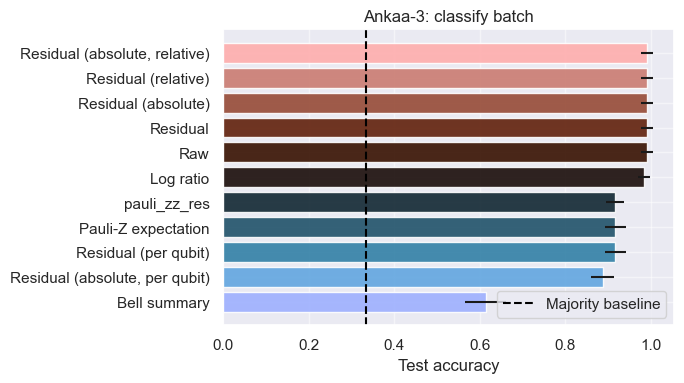

In [11]:
# Classification experiment...

device = "Ankaa-3"
features_to_run = [
    "raw",
    "res",
    "abs_res",
    "rel_res",
    "abs_rel_res",
    "log_ratio",
    "qubit_res",
    "abs_qubit_res",
    "pauli_z_res",
    "pauli_zz_res",
    "bell_summary",
]

specific_device_df = raw_data[raw_data["device"] == device].copy()
specific_device_df = balanced_subset(specific_device_df, group_cols="batch")

specific_device_results, specific_device_scores = feature_sweep(
    specific_device_df,
    feature_types=features_to_run,
    label_col="batch",
    classifier="logreg",
    repeats=5,
    epochs=500,
)

display(specific_device_results)
plot_feature_sweep(specific_device_results, title=f"{device}: classify batch")

Skipping Aria-1


,device,n_rows,n_classes,baseline_acc,train_acc_mean,test_acc_mean,test_acc_std,balanced_test_acc_mean,balanced_test_acc_std,feature_type,feature_name
0,Ankaa-3,300.0,3.0,0.333333,1.000000,0.990000,0.013333,0.990000,0.013333,raw,Raw
1,Ankaa-3,300.0,3.0,0.333333,1.000000,0.990000,0.013333,0.990000,0.013333,res,Residual
2,Ankaa-3,300.0,3.0,0.333333,1.000000,0.990000,0.013333,0.990000,0.013333,abs_res,Residual (absolute)
3,Ankaa-3,300.0,3.0,0.333333,1.000000,0.990000,0.013333,0.990000,0.013333,rel_res,Residual (relative)
4,Ankaa-3,300.0,3.0,0.333333,1.000000,0.990000,0.013333,0.990000,0.013333,abs_rel_res,"Residual (absolute, relative)"
5,Ankaa-3,300.0,3.0,0.333333,1.000000,0.983333,0.014907,0.983333,0.014907,log_ratio,Log ratio
6,Ankaa-3,300.0,3.0,0.333333,0.940833,0.916667,0.023570,0.916667,0.023570,qubit_res,Residual (per qubit)
7,Ankaa-3,300.0,3.0,0.333333,0.940833,0.916667,0.023570,0.916667,0.023570,pauli_z_res,Pauli-Z expectation
8,Ankaa-3,300.0,3.0,0.333333,0.895000,0.916667,0.021082,0.916667,0.021082,pauli_zz_res,pauli_zz_res
9,Ankaa-3,300.0,3.0,0.333333,0.877500,0.886667,0.026667,0.886667,0.026667,abs_qubit_res,"Residual (absolute, per qubit)"


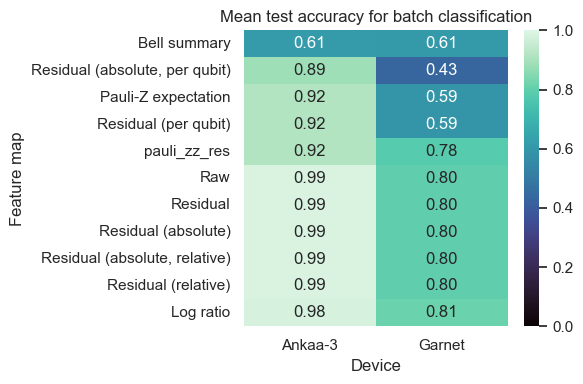

In [12]:
# Per-device sweep...

per_device_rows = []
per_device_raw_scores = []

for dev, dev_df in raw_data.groupby("device"):
    if dev_df["batch"].nunique() < 2:
        print(f"Skipping {dev}")
        continue

    dev_balanced = balanced_subset(dev_df, group_cols="batch")
    dev_results, dev_scores = feature_sweep(
        dev_balanced,
        feature_types=features_to_run,
        label_col="batch",
        classifier="logreg",
        repeats=5,
        epochs=500,
    )
    dev_results.insert(0, "device", dev)
    dev_scores.insert(0, "device", dev)
    per_device_rows.append(dev_results)
    per_device_raw_scores.append(dev_scores)

per_device_results = pd.concat(per_device_rows, ignore_index=True)
per_device_scores = pd.concat(per_device_raw_scores, ignore_index=True)

display(per_device_results.sort_values(["device", "test_acc_mean"], ascending=[True, False]))

grid = per_device_results.pivot(index="feature_name", columns="device", values="test_acc_mean")
grid = grid.loc[per_device_results.groupby("feature_name")["test_acc_mean"].mean().sort_values().index]

fig, ax = plt.subplots(figsize=(6, max(4, 0.35 * len(grid))))
sns.heatmap(grid, annot=True, fmt=".2f", cmap="mako", vmin=0, vmax=1, ax=ax)
ax.set_title("Mean test accuracy for batch classification")
ax.set_xlabel("Device")
ax.set_ylabel("Feature map")
plt.tight_layout()
plt.show()

,n_rows,n_classes,baseline_acc,train_acc_mean,test_acc_mean,test_acc_std,balanced_test_acc_mean,balanced_test_acc_std,device,batch_pair,feature_type,feature_name
5,200.0,2.0,0.5,1.00000,0.980,0.018708,0.980,0.018708,Ankaa-3,1 vs 2,log_ratio,Log ratio
0,200.0,2.0,0.5,1.00000,0.975,0.015811,0.975,0.015811,Ankaa-3,1 vs 2,raw,Raw
1,200.0,2.0,0.5,1.00000,0.975,0.015811,0.975,0.015811,Ankaa-3,1 vs 2,res,Residual
2,200.0,2.0,0.5,1.00000,0.975,0.015811,0.975,0.015811,Ankaa-3,1 vs 2,abs_res,Residual (absolute)
3,200.0,2.0,0.5,1.00000,0.975,0.015811,0.975,0.015811,Ankaa-3,1 vs 2,rel_res,Residual (relative)
...,...,...,...,...,...,...,...,...,...,...,...,...
60,200.0,2.0,0.5,0.95625,0.805,0.048477,0.805,0.048477,Garnet,2 vs 3,log_ratio,Log ratio
65,200.0,2.0,0.5,0.67250,0.690,0.081548,0.690,0.081548,Garnet,2 vs 3,bell_summary,Bell summary
61,200.0,2.0,0.5,0.69125,0.640,0.090277,0.640,0.090277,Garnet,2 vs 3,qubit_res,Residual (per qubit)
63,200.0,2.0,0.5,0.69125,0.640,0.090277,0.640,0.090277,Garnet,2 vs 3,pauli_z_res,Pauli-Z expectation


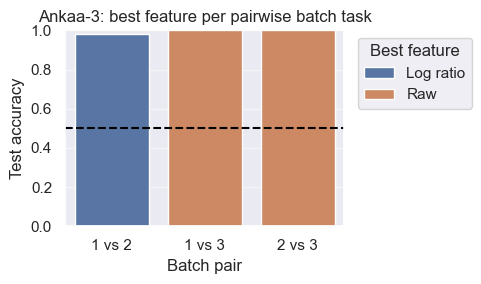

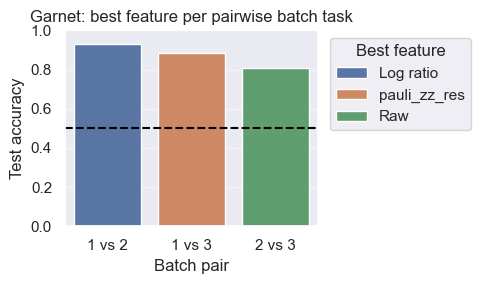

In [13]:
# Classifying batches pairwise...

def pairwise_batch_classification(data_df, feature_types=None, classifier="mlp", repeats=5, epochs=500):
    if feature_types is None:
        feature_types = features_to_run

    rows = []
    for dev, dev_df in data_df.groupby("device"):
        batches = sorted(dev_df["batch"].unique())
        if len(batches) < 2:
            continue
        for a, b in itertools.combinations(batches, 2):
            pair_df = dev_df[dev_df["batch"].isin([a, b])].copy()
            pair_df = balanced_subset(pair_df, group_cols="batch")
            for feature_type in feature_types:
                scores = experiment_run(
                    pair_df,
                    feature_type=feature_type,
                    label_col="batch",
                    classifier=classifier,
                    repeats=repeats,
                    epochs=epochs,
                )
                summary = summarize_scores(scores)
                summary["device"] = dev
                summary["batch_pair"] = f"{a} vs {b}"
                summary["feature_type"] = feature_type
                summary["feature_name"] = feature_name_map.get(feature_type, feature_type)
                rows.append(summary)
    return pd.DataFrame(rows)

pairwise_results = pairwise_batch_classification(
    raw_data[raw_data["device"].isin(["Ankaa-3", "Garnet"])],
    feature_types=features_to_run,
    classifier="logreg",
    repeats=5,
    epochs=500,
)

display(pairwise_results.sort_values(["device", "batch_pair", "test_acc_mean"], ascending=[True, True, False]))

for dev in pairwise_results["device"].unique():
    dev_best = pairwise_results[pairwise_results["device"] == dev]
    dev_best = dev_best.loc[dev_best.groupby("batch_pair")["test_acc_mean"].idxmax()]

    fig, ax = plt.subplots(figsize=(5, 3))
    sns.barplot(data=dev_best, x="batch_pair", y="test_acc_mean", hue="feature_name", dodge=False, ax=ax)
    ax.axhline(0.5, linestyle="--", color="black")
    ax.set_ylim(0, 1)
    ax.set_title(f"{dev}: best feature per pairwise batch task")
    ax.set_xlabel("Batch pair")
    ax.set_ylabel("Test accuracy")
    ax.legend(title="Best feature", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

## Controlled Pooled Experiment

We should also do batch classification across the superconducting devices jointly to identify whether the temporal signal is tied specifically to the device or rather present generally.

,n_rows,n_classes,baseline_acc,train_acc_mean,test_acc_mean,test_acc_std,balanced_test_acc_mean,balanced_test_acc_std,feature_type,feature_name
0,600.0,3.0,0.333333,0.868750,0.835000,0.012247,0.835000,0.012247,log_ratio,Log ratio
1,600.0,3.0,0.333333,0.875833,0.828333,0.006667,0.828333,0.006667,raw,Raw
2,600.0,3.0,0.333333,0.875833,0.828333,0.006667,0.828333,0.006667,res,Residual
3,600.0,3.0,0.333333,0.875833,0.828333,0.006667,0.828333,0.006667,abs_res,Residual (absolute)
4,600.0,3.0,0.333333,0.875833,0.828333,0.006667,0.828333,0.006667,rel_res,Residual (relative)
5,600.0,3.0,0.333333,0.875833,0.828333,0.006667,0.828333,0.006667,abs_rel_res,"Residual (absolute, relative)"
6,600.0,3.0,0.333333,0.726667,0.738333,0.029627,0.738333,0.029627,pauli_zz_res,pauli_zz_res
7,600.0,3.0,0.333333,0.619167,0.623333,0.043269,0.623333,0.043269,qubit_res,Residual (per qubit)
8,600.0,3.0,0.333333,0.619167,0.623333,0.043269,0.623333,0.043269,pauli_z_res,Pauli-Z expectation
9,600.0,3.0,0.333333,0.597500,0.568333,0.043906,0.568333,0.043906,abs_qubit_res,"Residual (absolute, per qubit)"


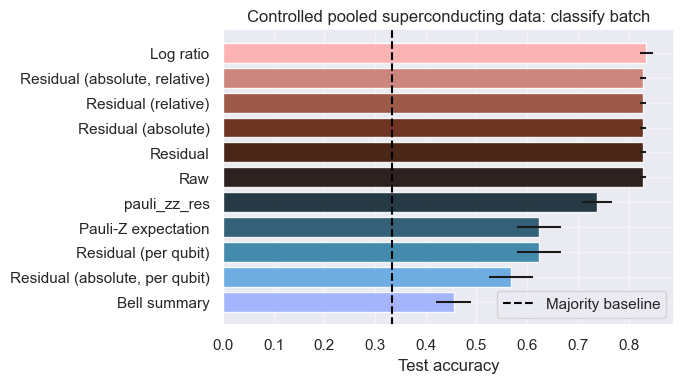

In [14]:
superconducting_df = raw_data[raw_data["device"].isin(["Ankaa-3", "Garnet"])].copy()
pooled_controlled_df = balanced_subset(superconducting_df, group_cols=["device", "batch"])

pooled_results, pooled_scores = feature_sweep(
    pooled_controlled_df,
    feature_types=features_to_run,
    label_col="batch",
    classifier="logreg",
    repeats=5,
    epochs=500,
)

display(pooled_results)
plot_feature_sweep(pooled_results, title="Controlled pooled superconducting data: classify batch")

## Negative Control Experiment

We should also make sure that the pipeline itself is not manufacturing the signal. We can define a negative control experiment by randomly permuting the labels within a device to create a gibberish dataset, and shoul observe classificiation accuracies drop back down ot the majority baseline.

,n_rows,n_classes,baseline_acc,train_acc_mean,test_acc_mean,test_acc_std,balanced_test_acc_mean,balanced_test_acc_std,feature_type,feature_name
0,300.0,3.0,0.333333,0.404167,0.360000,0.068799,0.360000,0.068799,abs_qubit_res,"Residual (absolute, per qubit)"
1,300.0,3.0,0.333333,0.395833,0.333333,0.034960,0.333333,0.034960,qubit_res,Residual (per qubit)
2,300.0,3.0,0.333333,0.395833,0.333333,0.034960,0.333333,0.034960,pauli_z_res,Pauli-Z expectation
3,300.0,3.0,0.333333,0.422500,0.333333,0.058689,0.333333,0.058689,pauli_zz_res,pauli_zz_res
4,300.0,3.0,0.333333,0.506667,0.320000,0.035590,0.320000,0.035590,log_ratio,Log ratio
5,300.0,3.0,0.333333,0.507500,0.293333,0.045461,0.293333,0.045461,raw,Raw
6,300.0,3.0,0.333333,0.507500,0.293333,0.045461,0.293333,0.045461,res,Residual
7,300.0,3.0,0.333333,0.507500,0.293333,0.045461,0.293333,0.045461,abs_res,Residual (absolute)
8,300.0,3.0,0.333333,0.507500,0.293333,0.045461,0.293333,0.045461,rel_res,Residual (relative)
9,300.0,3.0,0.333333,0.507500,0.293333,0.045461,0.293333,0.045461,abs_rel_res,"Residual (absolute, relative)"


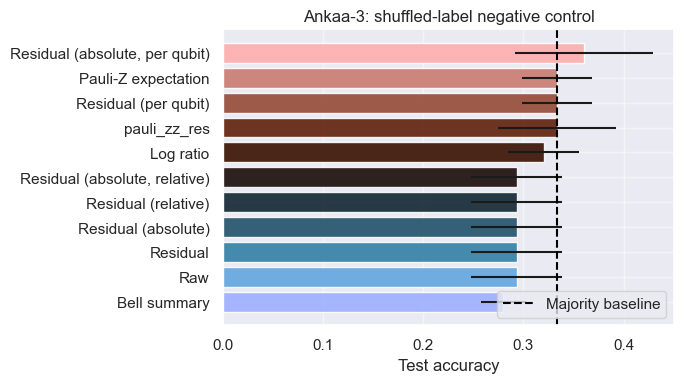

In [15]:
device = 'Ankaa-3'
specific_device_df = raw_data[raw_data["device"] == device].copy()
specific_device_df = balanced_subset(specific_device_df, group_cols="batch")

permuted_df = specific_device_df.copy()
permuted_df["batch_perm"] = rng.permutation(permuted_df["batch"].to_numpy())

permutation_results, permutation_scores = feature_sweep(
    permuted_df,
    feature_types=features_to_run,
    label_col="batch_perm",
    classifier="logreg",
    repeats=5,
    epochs=500,
)

display(permutation_results)
plot_feature_sweep(permutation_results, title=f"{device}: shuffled-label negative control")

,n_rows,n_classes,baseline_acc,train_acc_mean,test_acc_mean,test_acc_std,balanced_test_acc_mean,balanced_test_acc_std,feature_type,feature_name
0,300.0,3.0,0.333333,0.409167,0.360000,0.052281,0.360000,0.052281,abs_qubit_res,"Residual (absolute, per qubit)"
1,300.0,3.0,0.333333,0.404167,0.356667,0.048990,0.356667,0.048990,bell_summary,Bell summary
2,300.0,3.0,0.333333,0.555000,0.343333,0.020000,0.343333,0.020000,raw,Raw
3,300.0,3.0,0.333333,0.555000,0.343333,0.020000,0.343333,0.020000,res,Residual
4,300.0,3.0,0.333333,0.555000,0.343333,0.020000,0.343333,0.020000,abs_res,Residual (absolute)
5,300.0,3.0,0.333333,0.555000,0.343333,0.020000,0.343333,0.020000,rel_res,Residual (relative)
6,300.0,3.0,0.333333,0.555000,0.343333,0.020000,0.343333,0.020000,abs_rel_res,"Residual (absolute, relative)"
7,300.0,3.0,0.333333,0.555833,0.330000,0.022111,0.330000,0.022111,log_ratio,Log ratio
8,300.0,3.0,0.333333,0.405000,0.303333,0.072572,0.303333,0.072572,qubit_res,Residual (per qubit)
9,300.0,3.0,0.333333,0.405000,0.303333,0.072572,0.303333,0.072572,pauli_z_res,Pauli-Z expectation


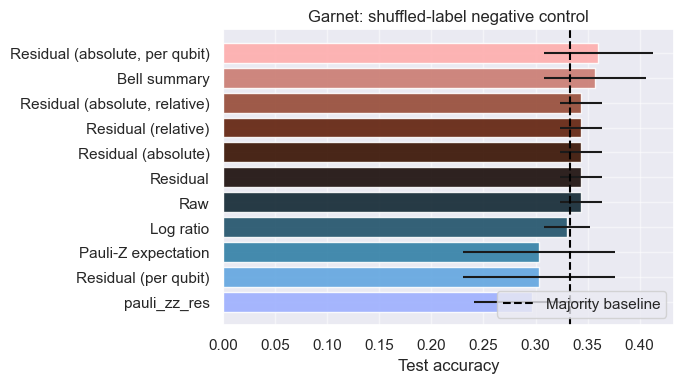

In [16]:
device = 'Garnet'
specific_device_df = raw_data[raw_data["device"] == device].copy()
specific_device_df = balanced_subset(specific_device_df, group_cols="batch")

permuted_df = specific_device_df.copy()
permuted_df["batch_perm"] = rng.permutation(permuted_df["batch"].to_numpy())

permutation_results, permutation_scores = feature_sweep(
    permuted_df,
    feature_types=features_to_run,
    label_col="batch_perm",
    classifier="logreg",
    repeats=5,
    epochs=500,
)

display(permutation_results)
plot_feature_sweep(permutation_results, title=f"{device}: shuffled-label negative control")

## Early vs Late Classification

If we portion up our batch into an earlier group and a later group, we can look at whether short-term drift is present/learnable within a batch.

,device,batch,n_rows,n_classes,baseline_acc,train_acc_mean,test_acc_mean,test_acc_std,balanced_test_acc_mean,balanced_test_acc_std,feature_type,feature_name
0,Ankaa-3,1,100.0,2.0,0.5,0.59625,0.535,0.092331,0.535,0.092331,bell_summary,Bell summary
1,Ankaa-3,1,100.0,2.0,0.5,0.79375,0.525,0.107819,0.525,0.107819,log_ratio,Log ratio
2,Ankaa-3,1,100.0,2.0,0.5,0.60750,0.510,0.091652,0.510,0.091652,pauli_zz_res,Two-qubit correlator
3,Ankaa-3,1,100.0,2.0,0.5,0.77750,0.490,0.058310,0.490,0.058310,raw,Raw
4,Ankaa-3,1,100.0,2.0,0.5,0.77750,0.490,0.058310,0.490,0.058310,res,Residual
...,...,...,...,...,...,...,...,...,...,...,...,...
72,Garnet,3,100.0,2.0,0.5,0.83375,0.575,0.075000,0.575,0.075000,abs_rel_res,"Residual (absolute, relative)"
73,Garnet,3,100.0,2.0,0.5,0.69875,0.560,0.076811,0.560,0.076811,pauli_zz_res,Two-qubit correlator
74,Garnet,3,100.0,2.0,0.5,0.60750,0.525,0.090139,0.525,0.090139,qubit_res,Residual (per qubit)
75,Garnet,3,100.0,2.0,0.5,0.60750,0.525,0.090139,0.525,0.090139,pauli_z_res,Pauli-Z expectation


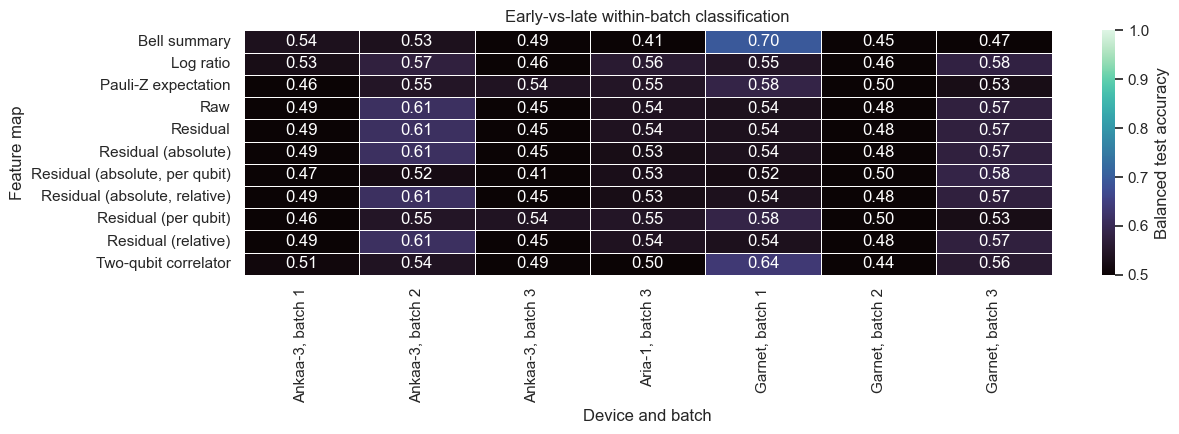

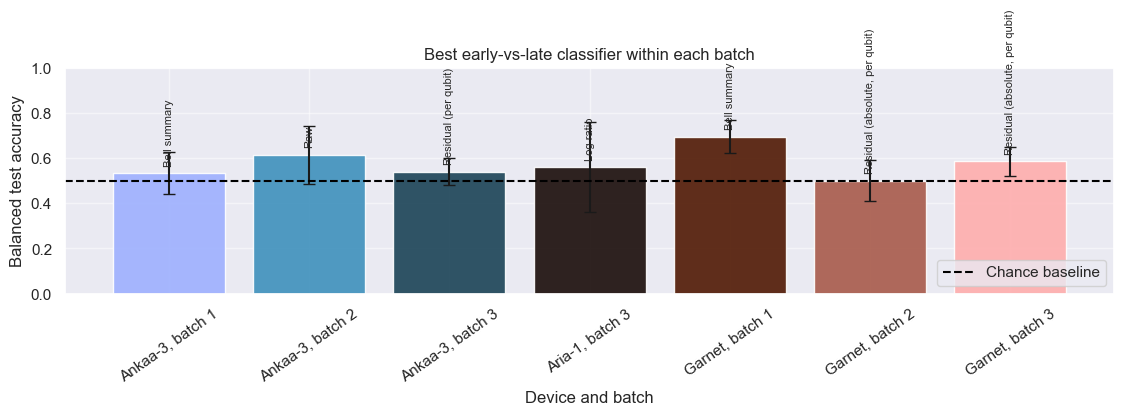

In [26]:
def add_time_half_label(data_df):
    pieces = []
    for _, group in data_df.sort_values("completion_time").groupby(["device", "batch"], group_keys=False):
        group = group.sort_values("completion_time").copy()
        midpoint = len(group) // 2
        group["time_half"] = ["early"] * midpoint + ["late"] * (len(group) - midpoint)
        pieces.append(group)
    return pd.concat(pieces, ignore_index=True)


within_rows = []
for (dev, batch), group in raw_data.groupby(["device", "batch"]):
    if len(group) < 30:
        continue
    half_df = add_time_half_label(group)
    half_df = balanced_subset(half_df, group_cols="time_half")
    half_results, _ = feature_sweep(
        half_df,
        feature_types=features_to_run,
        label_col="time_half",
        classifier="logreg",
        repeats=10,
        epochs=500,
    )
    half_results.insert(0, "device", dev)
    half_results.insert(1, "batch", batch)
    within_rows.append(half_results)

within_batch_results = pd.concat(within_rows, ignore_index=True)
display(within_batch_results.sort_values(["device", "batch", "test_acc_mean"], ascending=[True, True, False]))

score_col = "balanced_test_acc_mean"
err_col = "balanced_test_acc_std"

plot_df = within_batch_results.copy()
plot_df["device_batch"] = (
    plot_df["device"].astype(str) + ", batch " + plot_df["batch"].astype(str)
)

# Keep device/batch columns in chronological-ish order.
device_batch_order = (
    plot_df[["device", "batch", "device_batch"]]
    .drop_duplicates()
    .sort_values(["device", "batch"])["device_batch"]
    .tolist()
)

# 1. Heatmap: all feature maps across all device/batch cells.
heatmap_df = plot_df.pivot(
    index="feature_name",
    columns="device_batch",
    values=score_col,
)
heatmap_df = heatmap_df[device_batch_order]

fig, ax = plt.subplots(figsize=(1.4 * len(device_batch_order) + 3, 4.5))
sns.heatmap(
    heatmap_df,
    annot=True,
    fmt=".2f",
    cmap="mako",
    vmin=0.5,
    vmax=1.0,
    linewidths=0.5,
    cbar_kws={"label": "Balanced test accuracy"},
    ax=ax,
)
ax.set_title("Early-vs-late within-batch classification")
ax.set_xlabel("Device and batch")
ax.set_ylabel("Feature map")
plt.tight_layout()
plt.show()


# 2. Bar plot: best feature map for each device/batch cell.
best_df = plot_df.loc[
    plot_df.groupby("device_batch")[score_col].idxmax()
].copy()
best_df["device_batch"] = pd.Categorical(
    best_df["device_batch"],
    categories=device_batch_order,
    ordered=True,
)
best_df = best_df.sort_values("device_batch")

fig, ax = plt.subplots(figsize=(1.2 * len(best_df) + 3, 4))
bars = ax.bar(
    best_df["device_batch"].astype(str),
    best_df[score_col],
    yerr=best_df[err_col],
    capsize=4,
    color=[colours(i / max(1, len(best_df) - 1)) for i in range(len(best_df))],
    alpha=0.9,
)

ax.axhline(0.5, linestyle="--", color="black", label="Chance baseline")
ax.set_ylim(0.0, 1.0)
ax.set_ylabel("Balanced test accuracy")
ax.set_xlabel("Device and batch")
ax.set_title("Best early-vs-late classifier within each batch")
ax.tick_params(axis="x", rotation=35)
ax.legend(loc="lower right")

for bar, feature_name in zip(bars, best_df["feature_name"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.03,
        feature_name,
        ha="center",
        va="bottom",
        rotation=90,
        fontsize=8,
    )

plt.tight_layout()
plt.show()

## Shot-Resolution Checks

We can also have a look at how classification performance depends on shot count / fingerprint resolution.

,n_rows,n_classes,baseline_acc,train_acc_mean,test_acc_mean,test_acc_std,balanced_test_acc_mean,balanced_test_acc_std,shots,feature_type
0,300.0,3.0,0.333333,0.620000,0.440000,0.045461,0.440000,0.045461,16.0,raw
1,300.0,3.0,0.333333,0.662500,0.516667,0.048305,0.516667,0.048305,32.0,raw
2,300.0,3.0,0.333333,0.767500,0.643333,0.037417,0.643333,0.037417,64.0,raw
3,300.0,3.0,0.333333,0.840000,0.706667,0.050111,0.706667,0.050111,128.0,raw
4,300.0,3.0,0.333333,0.933333,0.820000,0.033993,0.820000,0.033993,256.0,raw
5,300.0,3.0,0.333333,0.961667,0.900000,0.018257,0.900000,0.018257,512.0,raw
6,300.0,3.0,0.333333,0.987500,0.936667,0.026667,0.936667,0.026667,1024.0,raw


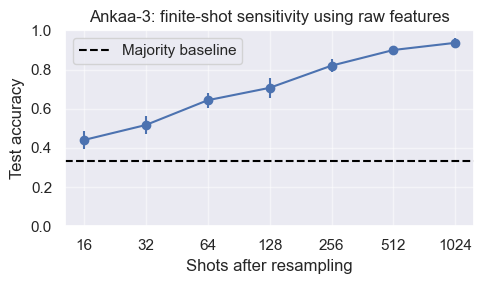

In [29]:
def multinomial_resample_rows(data_df, shots, random_state=seed):
    local_rng = np.random.default_rng(random_state)
    p = observed_matrix(data_df)
    sampled = np.vstack([local_rng.multinomial(shots, row) / shots for row in p])
    out = data_df.copy()
    out.loc[:, x_cols] = sampled
    out.loc[:, "n_shots"] = shots
    return out


shot_rows = []
for shots in [16, 32, 64, 128, 256, 512, 1024]:
    resampled = multinomial_resample_rows(specific_device_df, shots, random_state=seed + shots)
    scores = experiment_run(
        resampled,
        feature_type='raw',
        label_col="batch",
        classifier="logreg",
        repeats=5,
        epochs=500,
    )
    summary = summarize_scores(scores)
    summary["shots"] = shots
    summary["feature_type"] = 'raw'
    shot_rows.append(summary)

shot_results = pd.DataFrame(shot_rows)
display(shot_results)

fig, ax = plt.subplots(figsize=(5, 3))
ax.errorbar(
    shot_results["shots"],
    shot_results["test_acc_mean"],
    yerr=shot_results["test_acc_std"],
    marker="o",
)
ax.axhline(shot_results["baseline_acc"].iloc[0], linestyle="--", color="black", label="Majority baseline")
ax.set_xscale("log", base=2)
ax.set_xticks(shot_results["shots"])
ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
ax.set_ylim(0, 1)
ax.set_xlabel("Shots after resampling")
ax.set_ylabel("Test accuracy")
ax.set_title(f"{device}: finite-shot sensitivity using raw features")
ax.legend()
plt.tight_layout()
plt.show()